To inspect individuals ROIs (individual cells) for experimentally determined donor-lifetime trace and best-fit. 

In [31]:
import pandas as pd
import time
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import tkinter as tk
from tkinter import filedialog
from AutomatedCellAnalysis.get_cell_image import get_cell_image

In [32]:
ROOT = tk.Tk()
ROOT.withdraw() #closes the tkinter window again. just a cleanup
ROOT.attributes('-topmost', True)
users_base_path = filedialog.askopenfilename(title="Choose a single well fit file", filetype=(('csv files', '*.csv'),("all files", "*.*")))
fileName=users_base_path.split("/")[-1] # next, determine the names of the corresponding _fit.csv and _tau.csv files
resultpath=users_base_path.rstrip(fileName)# the path without the filename
users_base_path = Path(users_base_path)
labelmap_pth = Path(users_base_path.parent.parent,'intensity_data',users_base_path.name[:-8]+'_I_mean_labelmap.tif')
meanimg_pth = Path(users_base_path.parent.parent,'intensity_data',users_base_path.name[:-8]+'_I_mean.tif')
wellName=fileName[0:len(fileName)-8]
resultfile = wellName+'_tau.csv' 
fitfile = wellName+'_fit.csv'
print(users_base_path)

C:\Users\thinkBookUser\Desktop\Screening_Data_Analyzed\2019\11\07\chemical\results\B05_fit.csv


In [33]:
#<<<<<BLOCK: some settings to shape the inspection flow
autoScroll=True
fixYScale = True
max_nroi=25 #<<<<<<<<<< adjust this one to set how many are plotted maximally per well
scrollTime=0.5        #autoscroll delay, in s

In [34]:
fit = pd.read_csv(Path(resultpath,fitfile))
condition=fit['condition'][0]
lifetimetraces = np.loadtxt(Path(resultpath,resultfile))
frameinterval = fit['frameinterval(s)'][0]
forskendpoint = True # or false, depending if you have chemical stimulation or caged-cAMP release
nroi = min(lifetimetraces.shape[0], max_nroi) #plot no more than max_nroi cells if they exist
ntime = lifetimetraces.shape[1]
fit_sel = fit[fit['breakdown_time(s)'] > 2]#these are conditions added by Rolf to reject some cells\n",
#fit_sel = fit_sel[fit_sel['error']==0]  #<<<<<<<<<<<<<< If you want to see all the data, then comment this out
print('There are '+ str(len(lifetimetraces)) +' individual cells in the FOV of well '+wellName)
print('There are '+ str(len(fit_sel)) +' individual cells that qualify as a good-enough fit')
print('Frameinterval was '+ str(round(frameinterval,1)) + ' seconds')

There are 453 individual cells in the FOV of well B05
There are 73 individual cells that qualify as a good-enough fit
Frameinterval was 4.9 seconds


In [35]:
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c))

In [36]:
# to tune the graphs font sizes
plt.rc('font', size=20)          # controls default text sizes
#plt.rc('axes', titlesize=20)     # fontsize of the axes title
#plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
#plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
#plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
#plt.rc('legend', fontsize=12)    # legend fontsize
#plt.rc('figure', titlesize=22)  # fontsize of the figure title

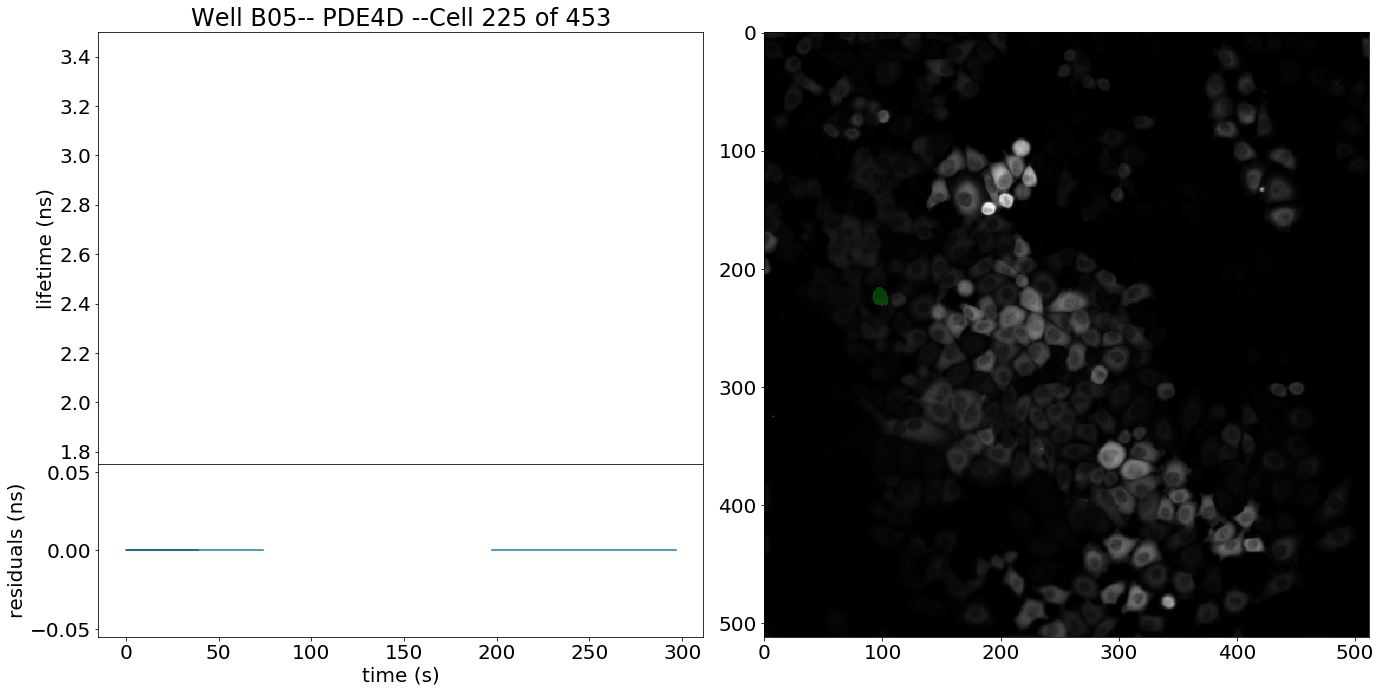

RMSD = nan ns     MAPE = nan %
    --


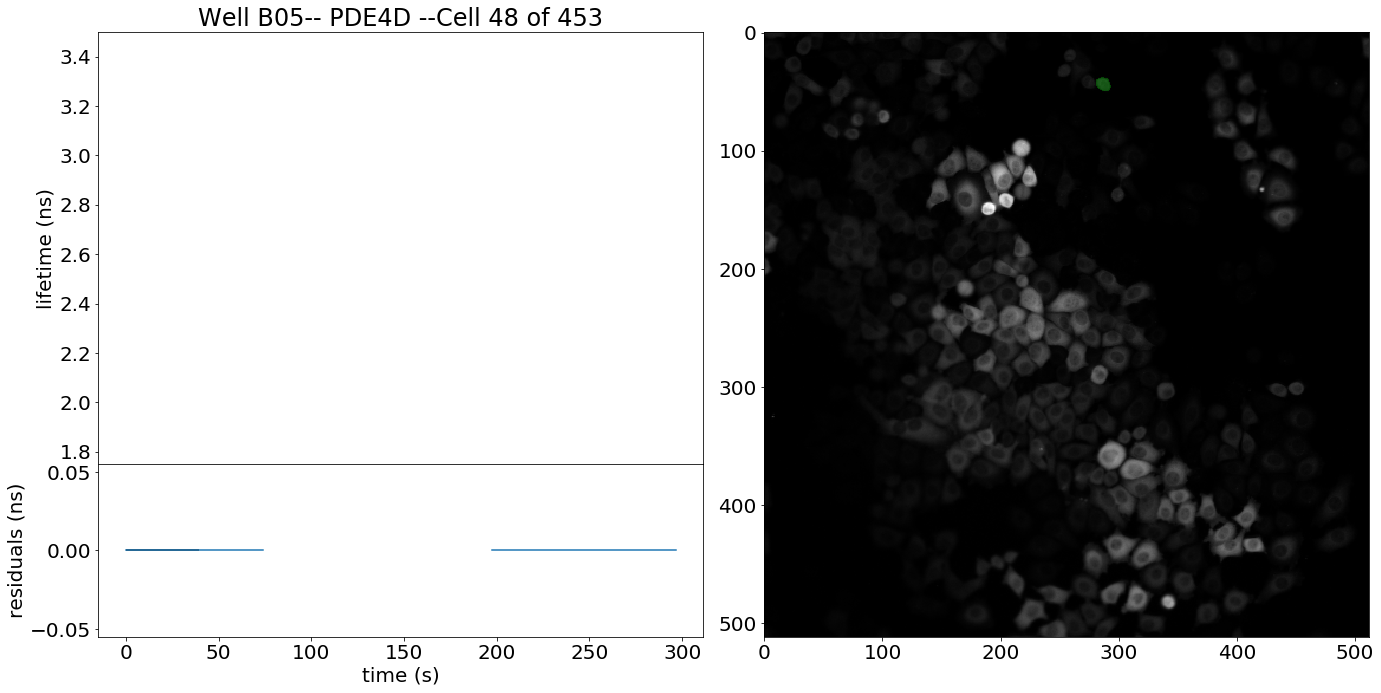

RMSD = nan ns     MAPE = nan %
    --


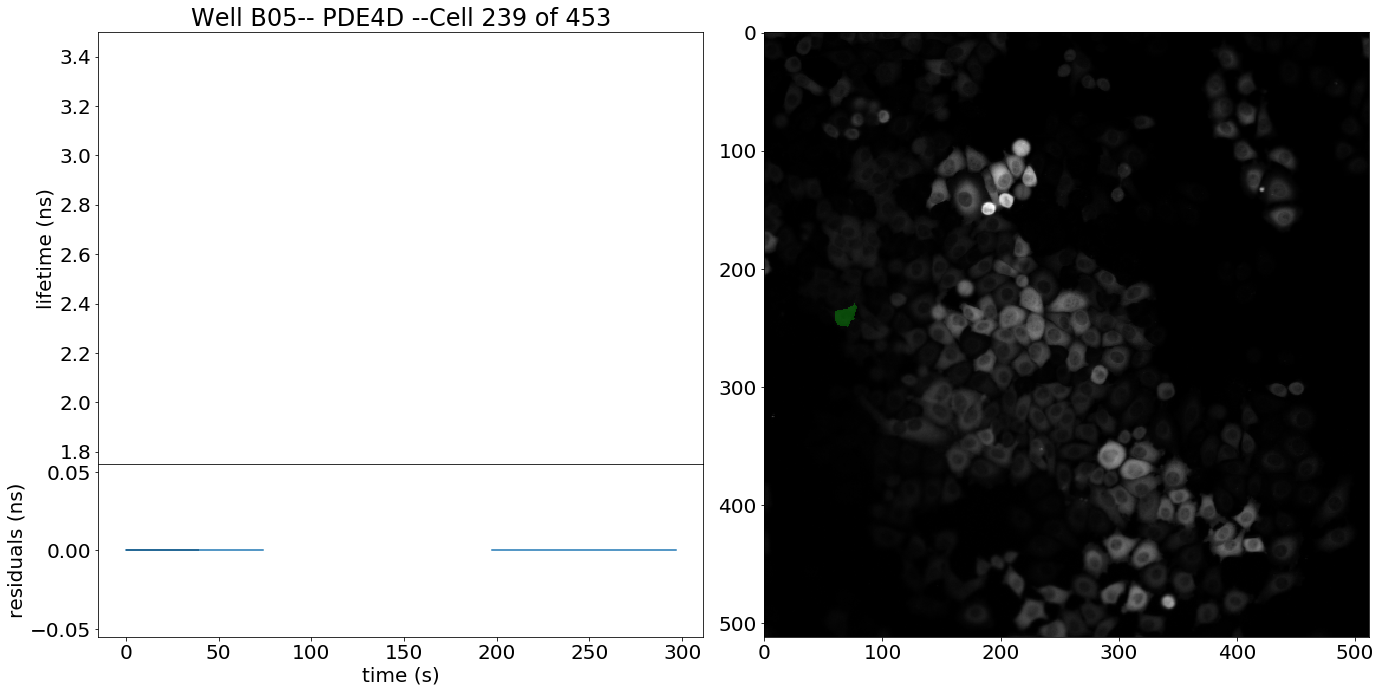

RMSD = nan ns     MAPE = nan %
    --


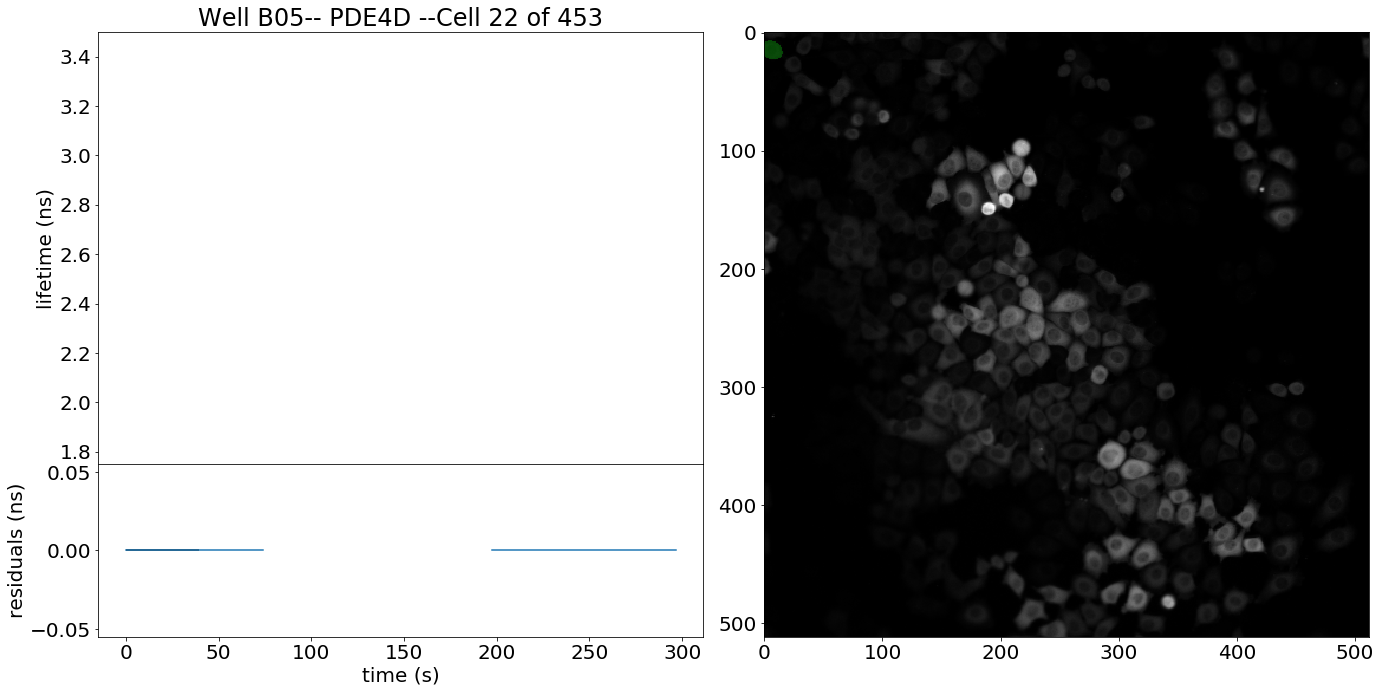

RMSD = nan ns     MAPE = nan %
    --


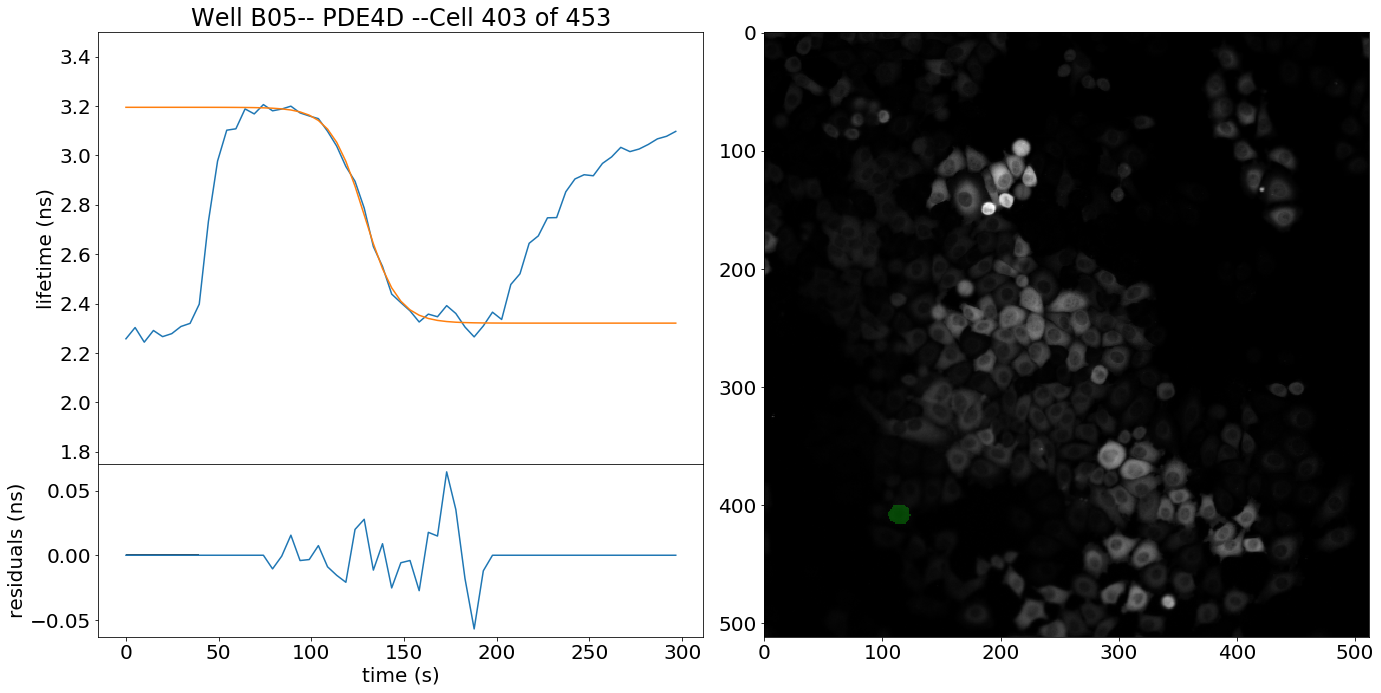

RMSD = 0.024 ns     MAPE = 0.7 %
    --


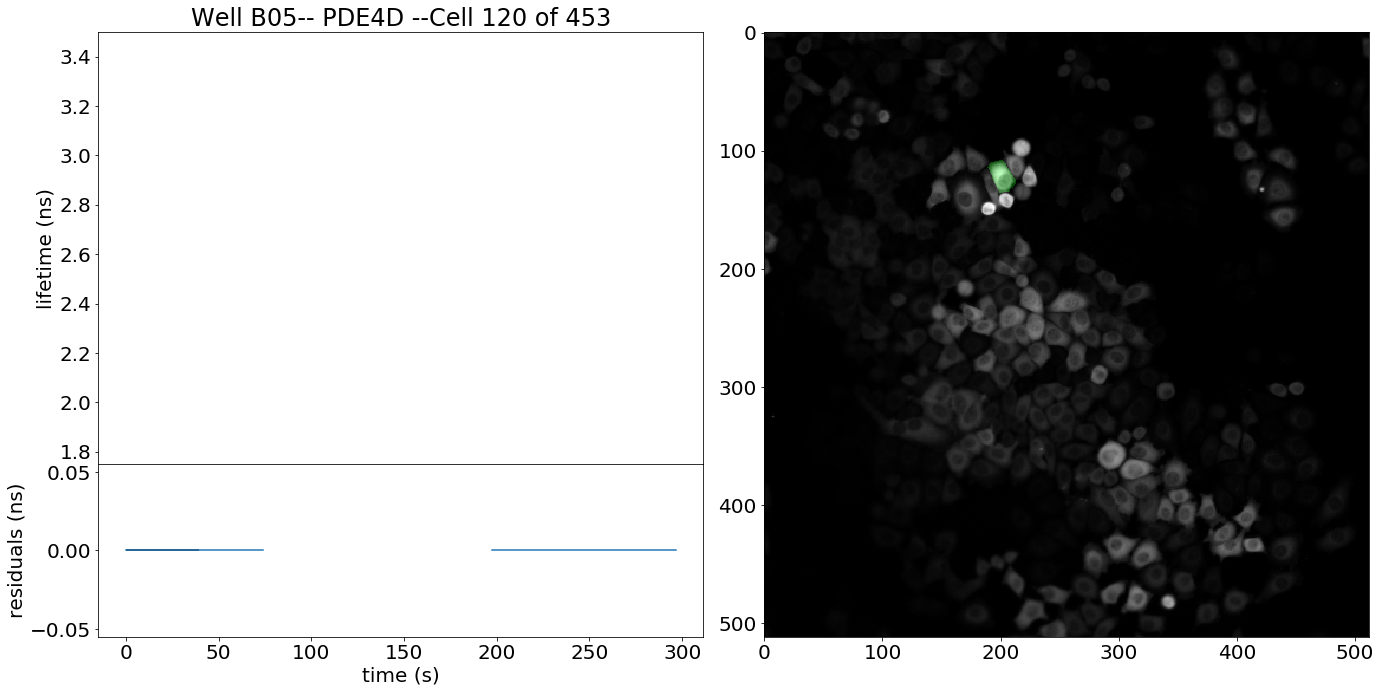

RMSD = nan ns     MAPE = nan %
    --


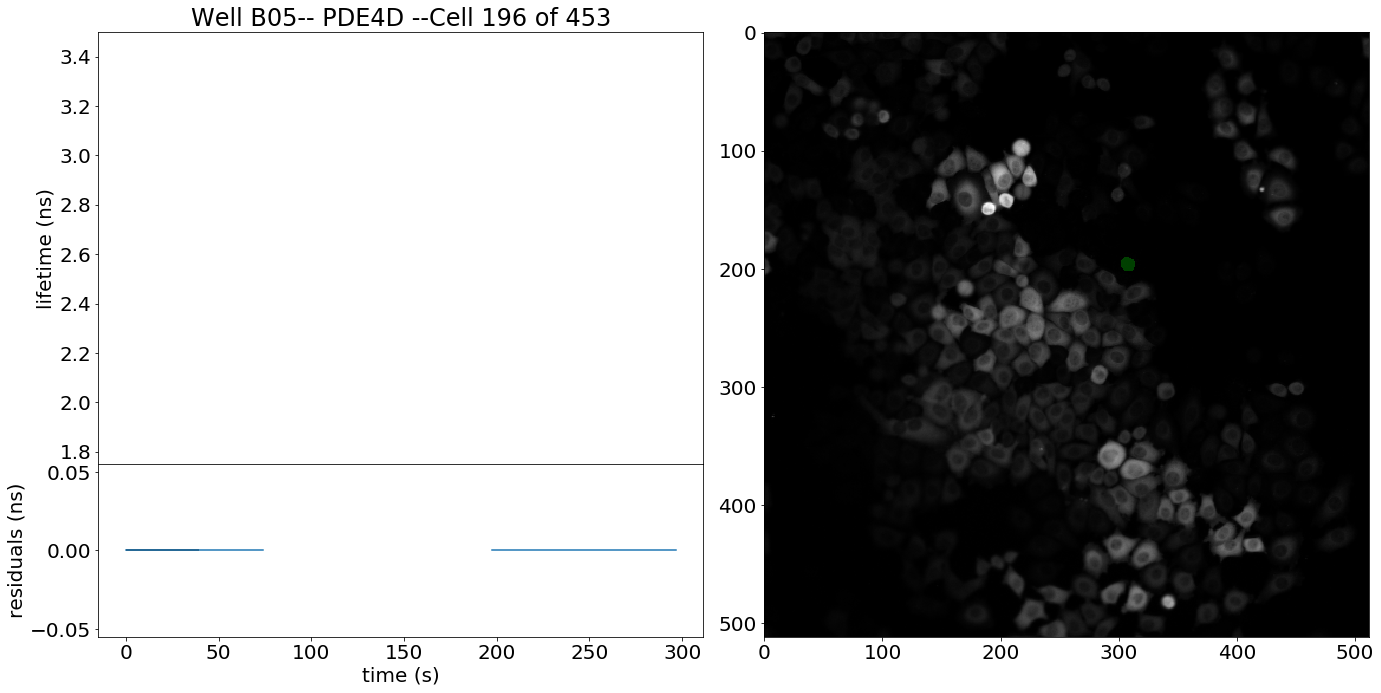

RMSD = nan ns     MAPE = nan %
    --


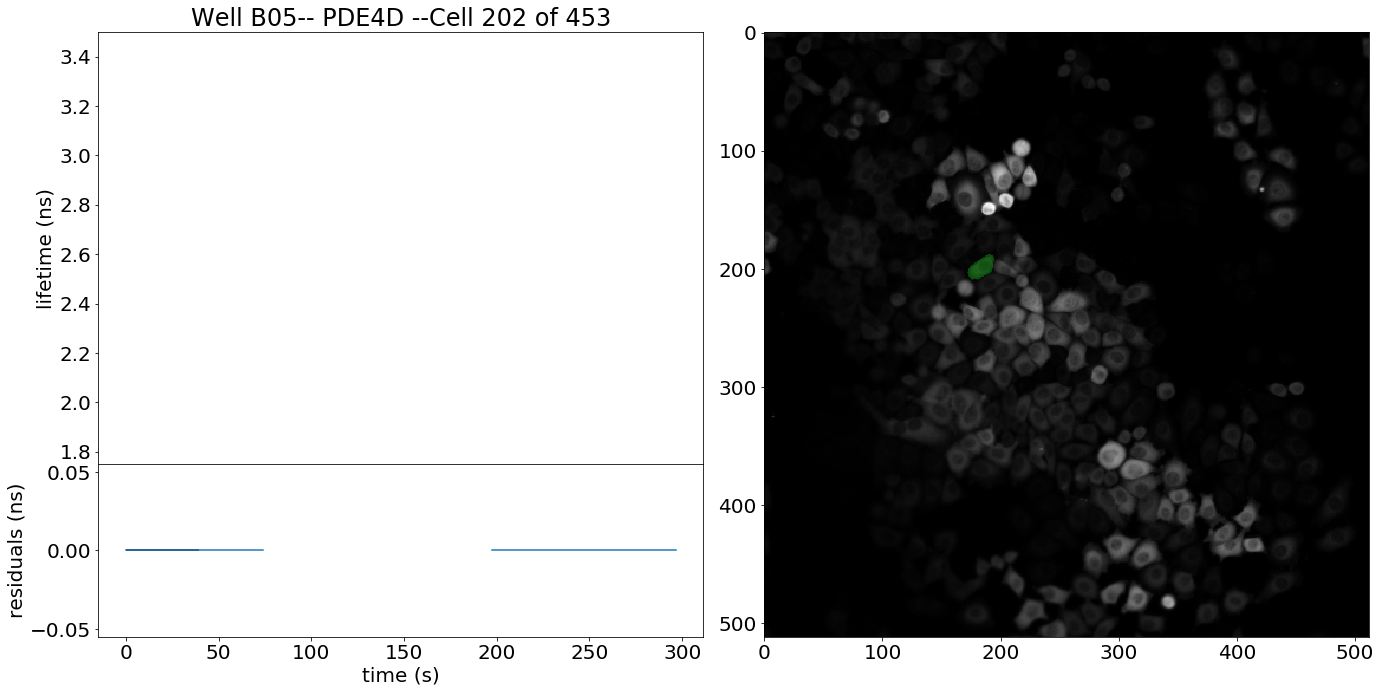

RMSD = nan ns     MAPE = nan %
    --


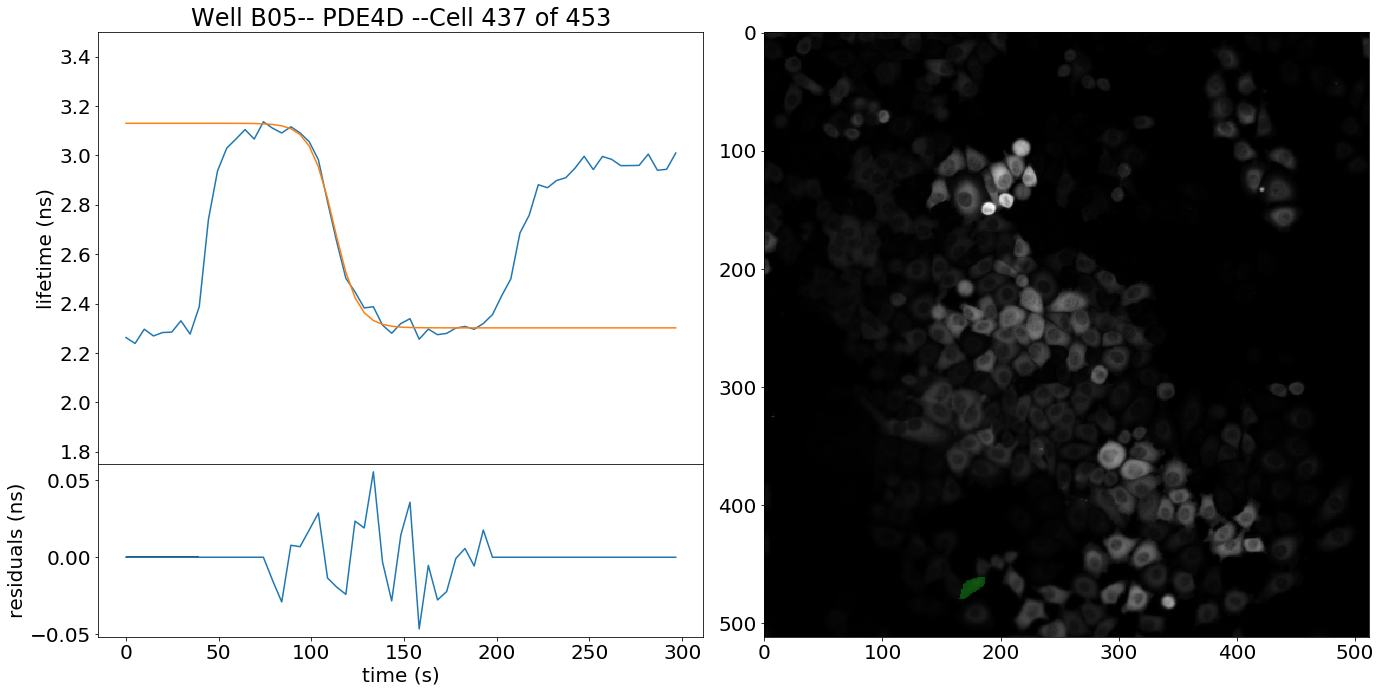

RMSD = 0.024 ns     MAPE = 0.8 %
    --


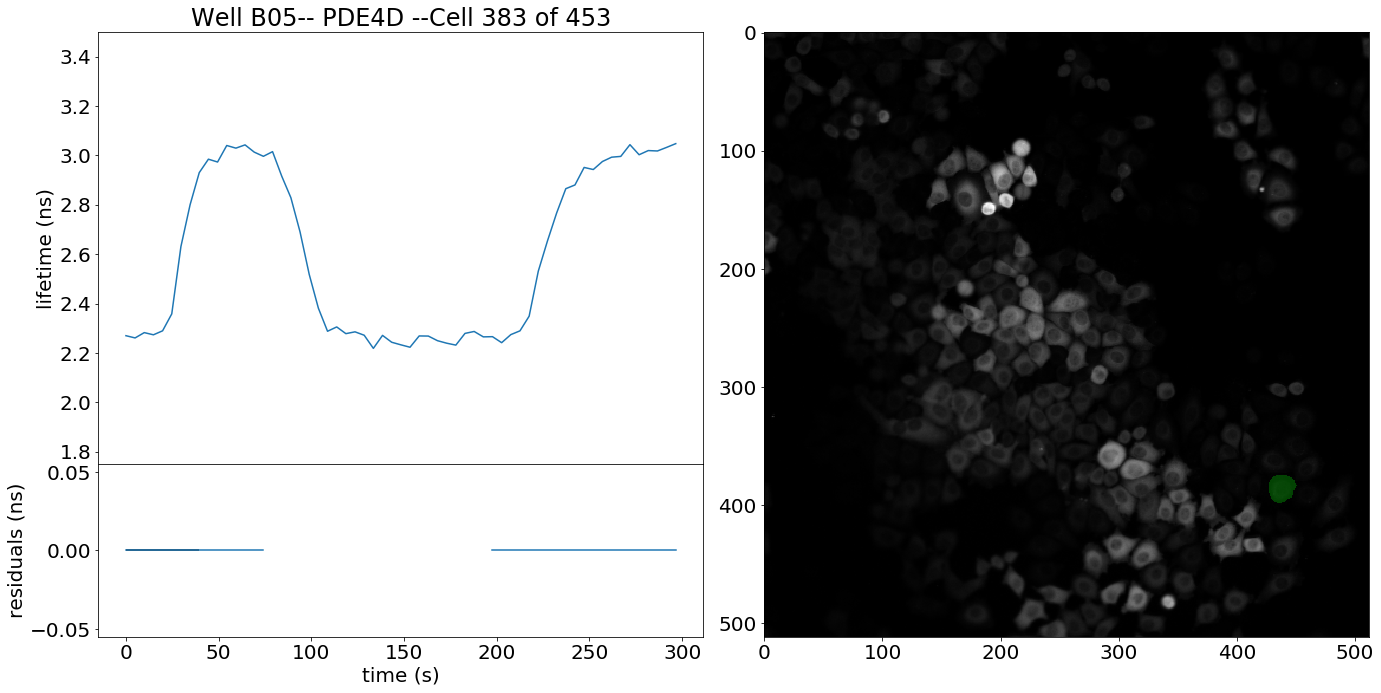

RMSD = nan ns     MAPE = nan %
    --


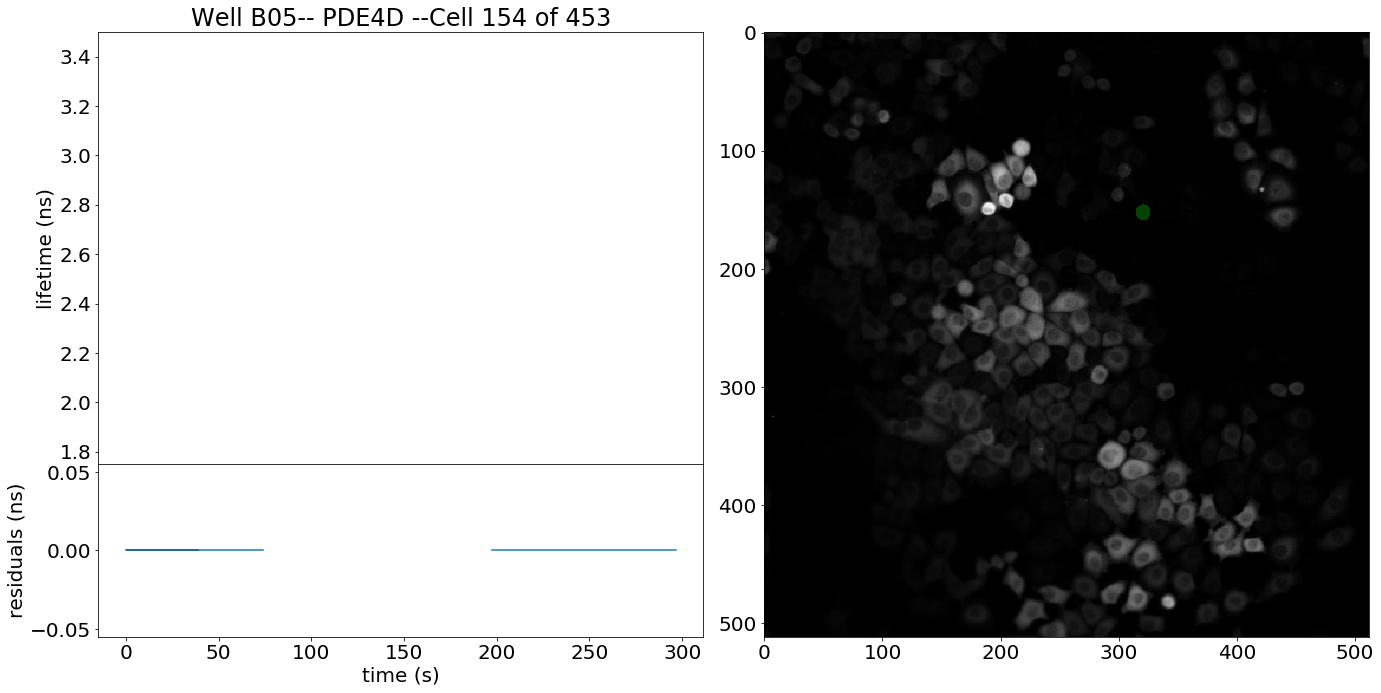

RMSD = nan ns     MAPE = nan %
    --


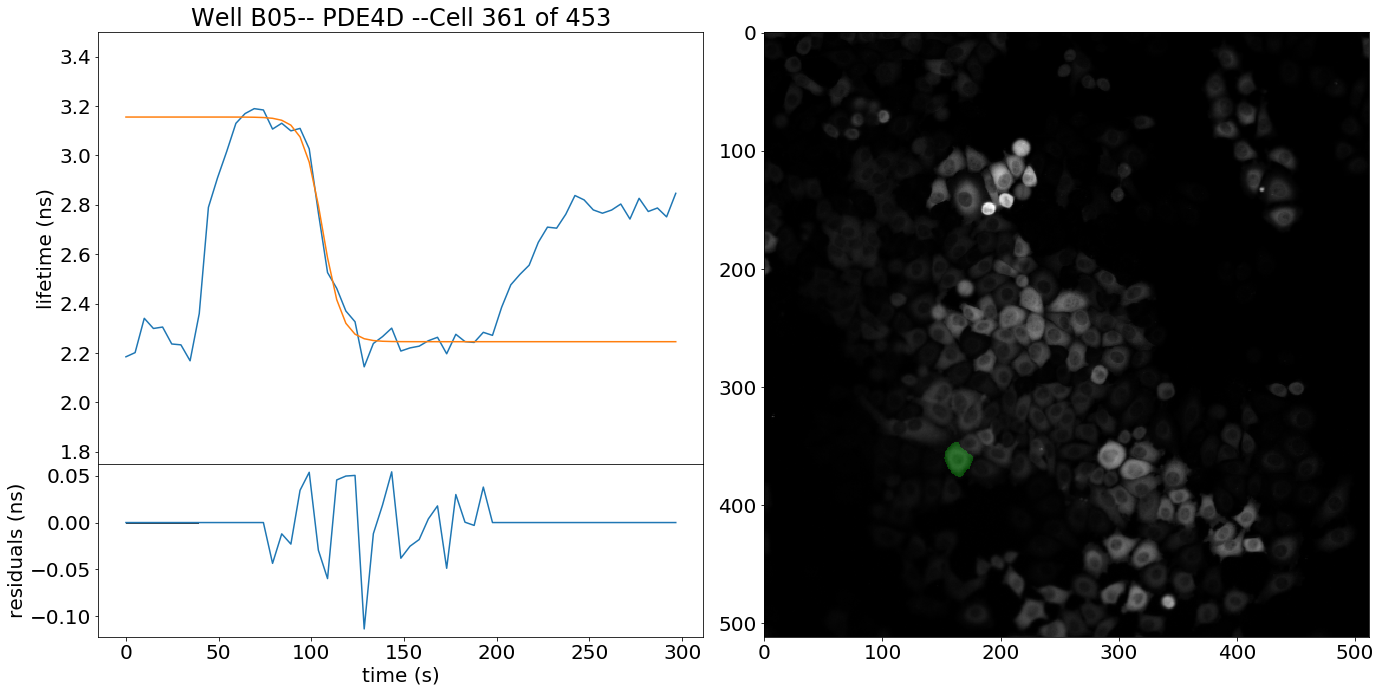

RMSD = 0.042 ns     MAPE = 1.4 %
    --


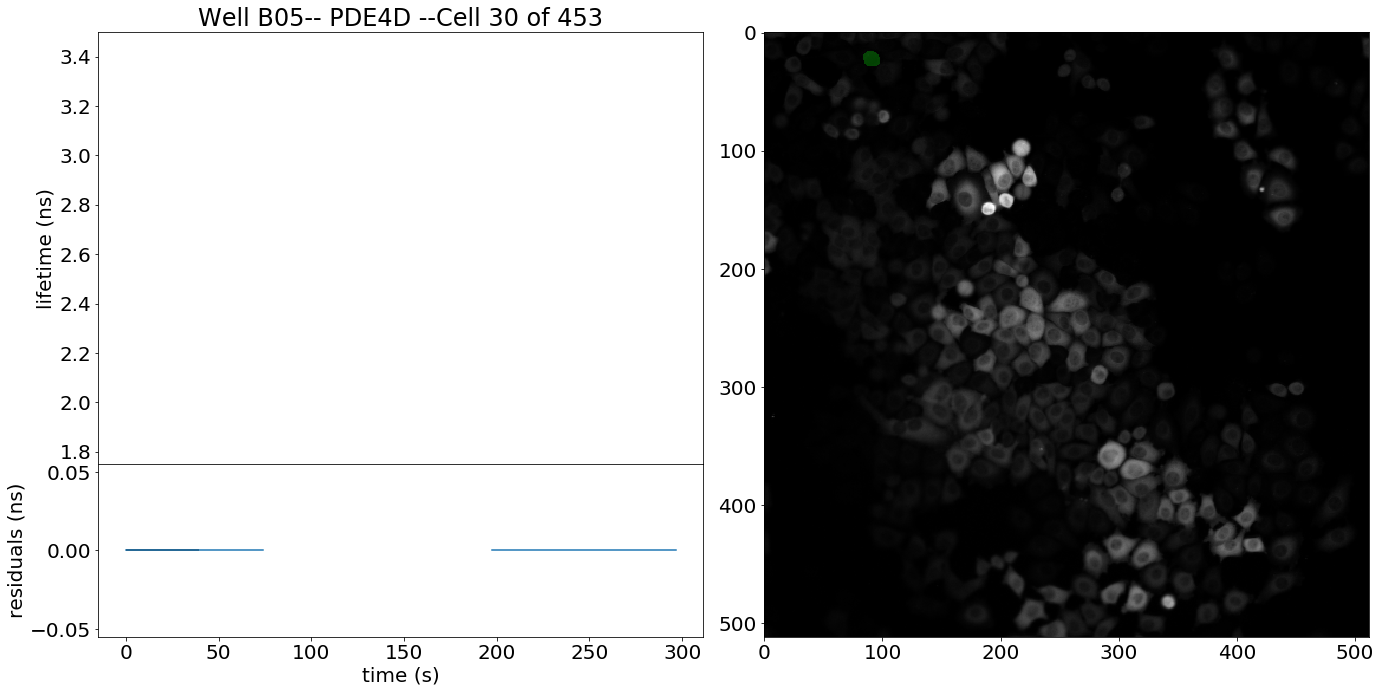

RMSD = nan ns     MAPE = nan %
    --


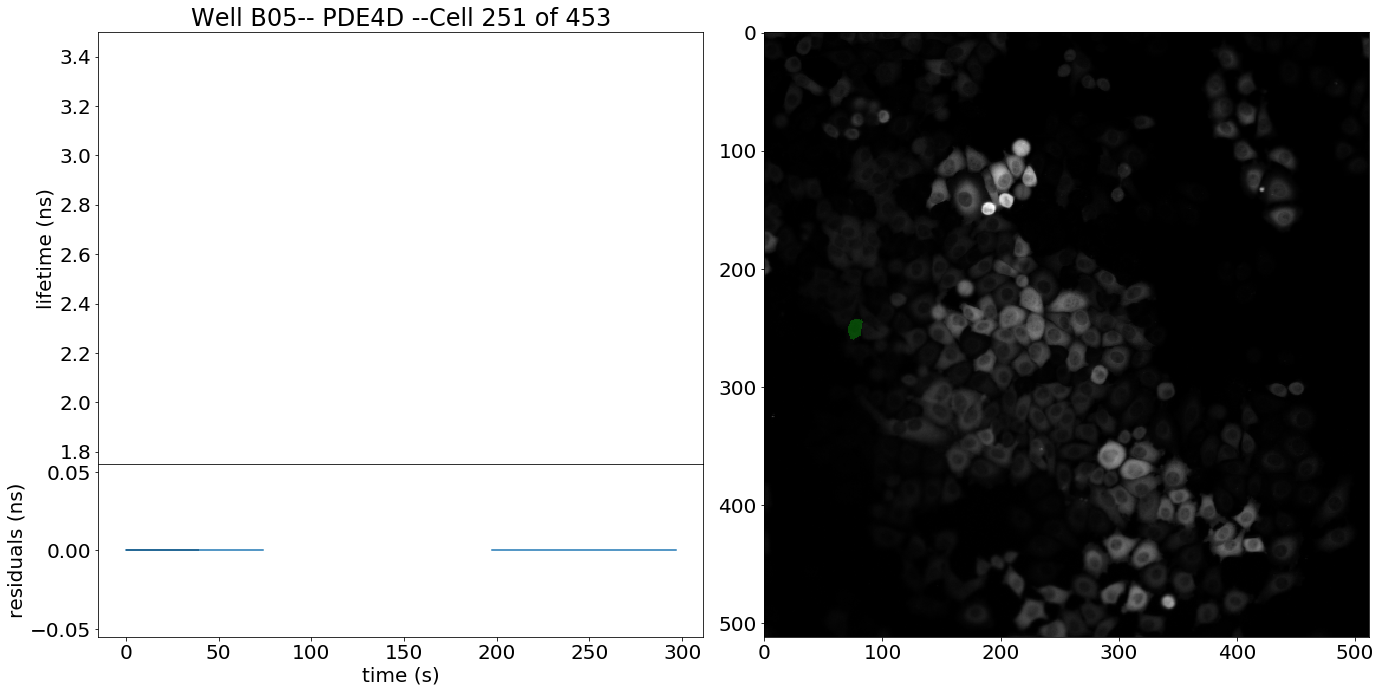

RMSD = nan ns     MAPE = nan %
    --


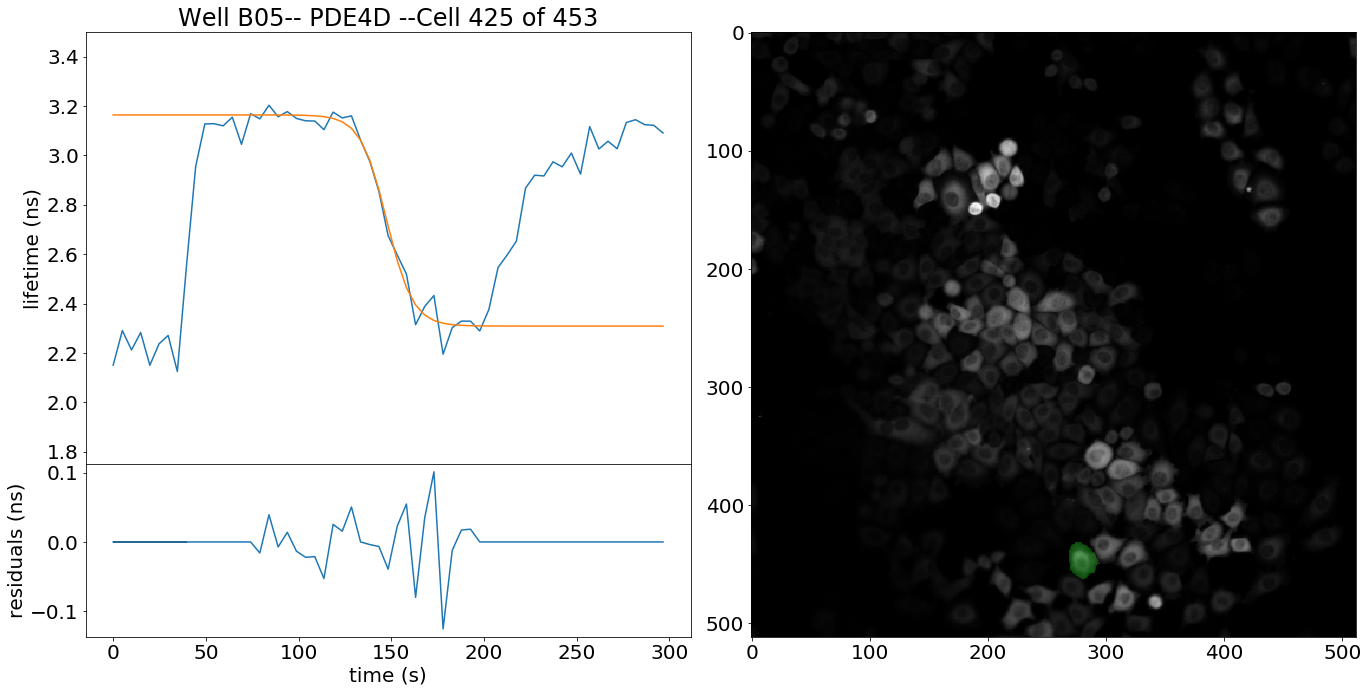

RMSD = 0.045 ns     MAPE = 1.3 %
    --


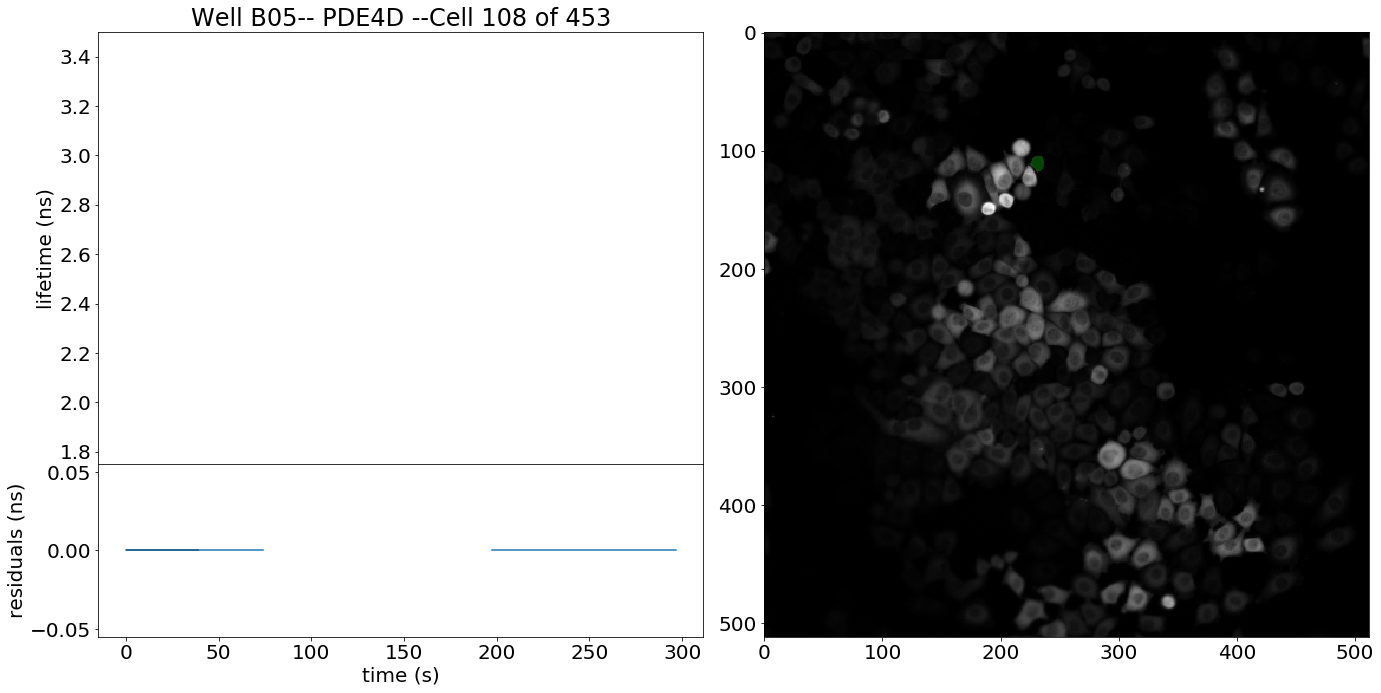

RMSD = nan ns     MAPE = nan %
    --


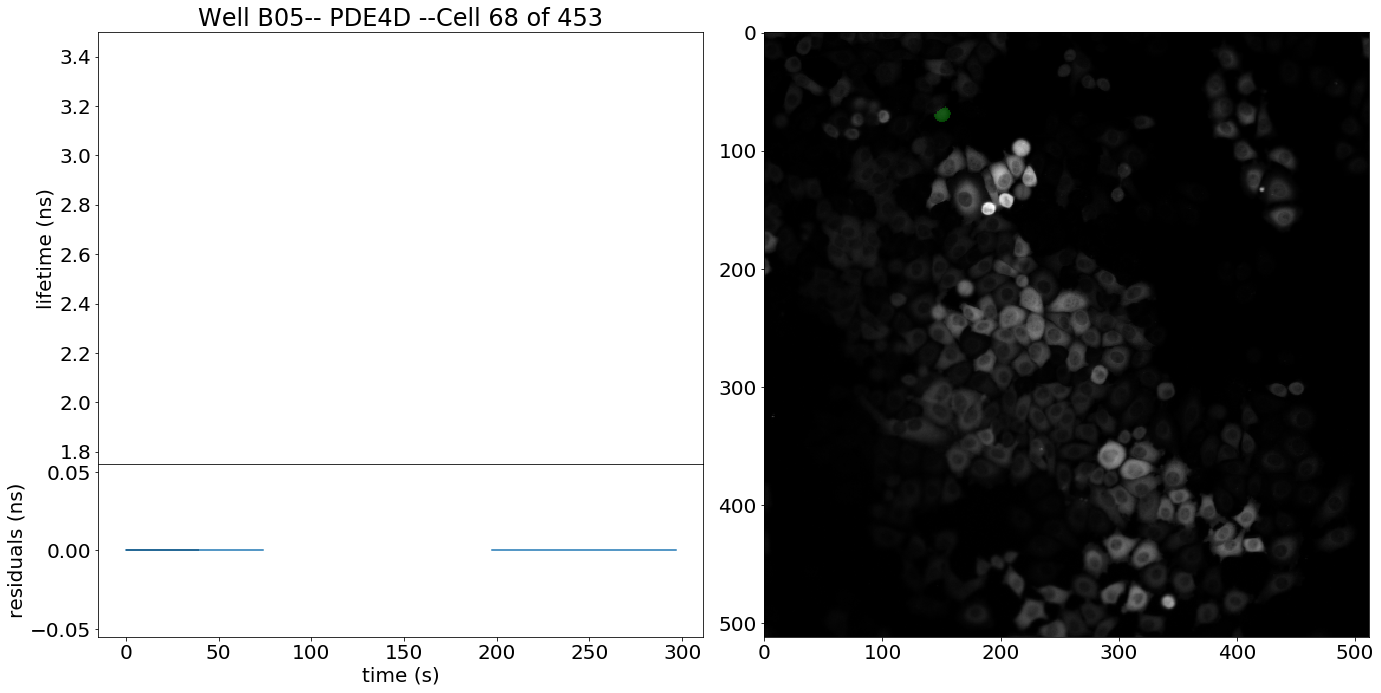

RMSD = nan ns     MAPE = nan %
    --


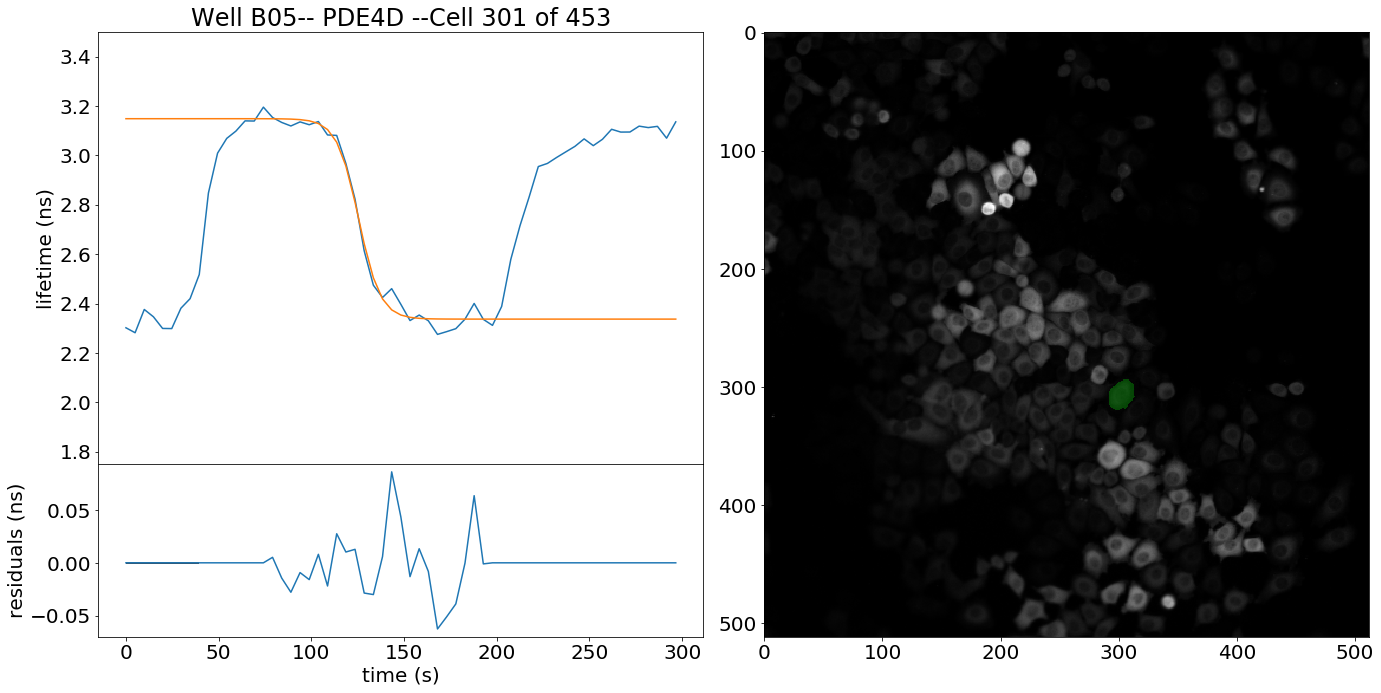

RMSD = 0.033 ns     MAPE = 1.0 %
    --


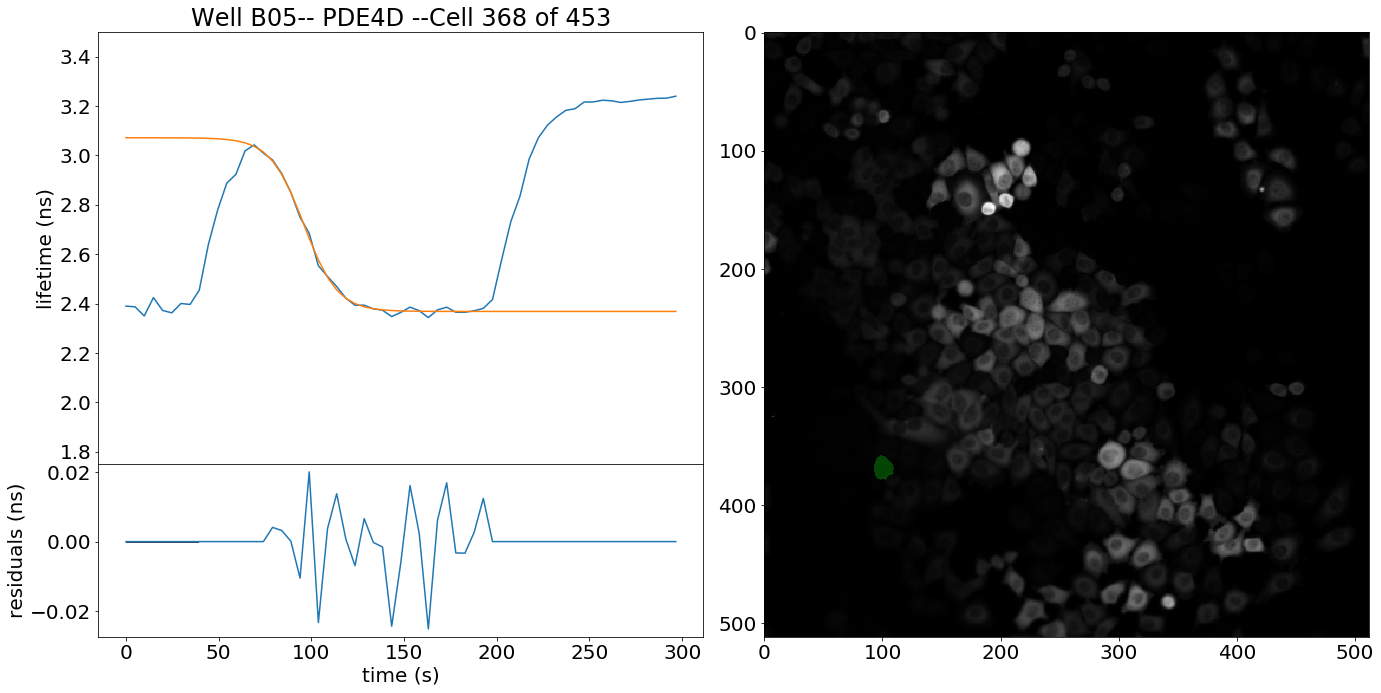

RMSD = 0.012 ns     MAPE = 0.4 %
    --


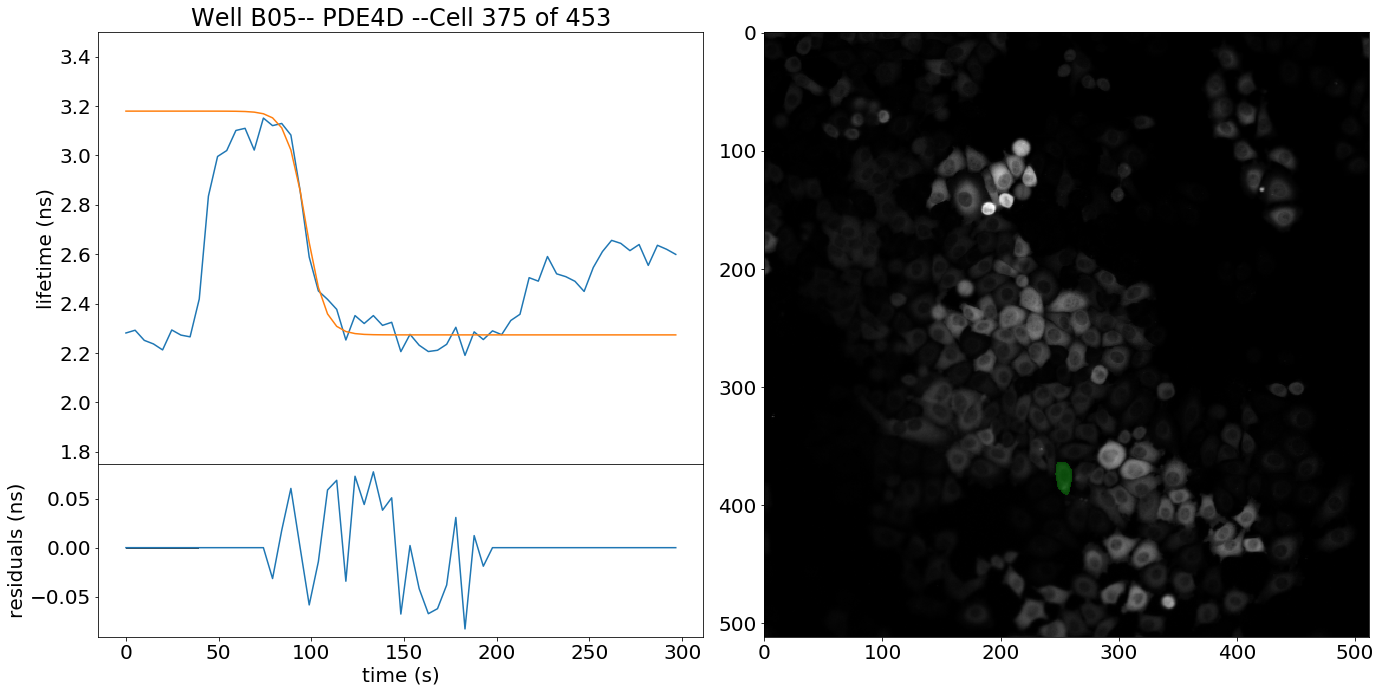

RMSD = 0.050 ns     MAPE = 1.9 %
    --


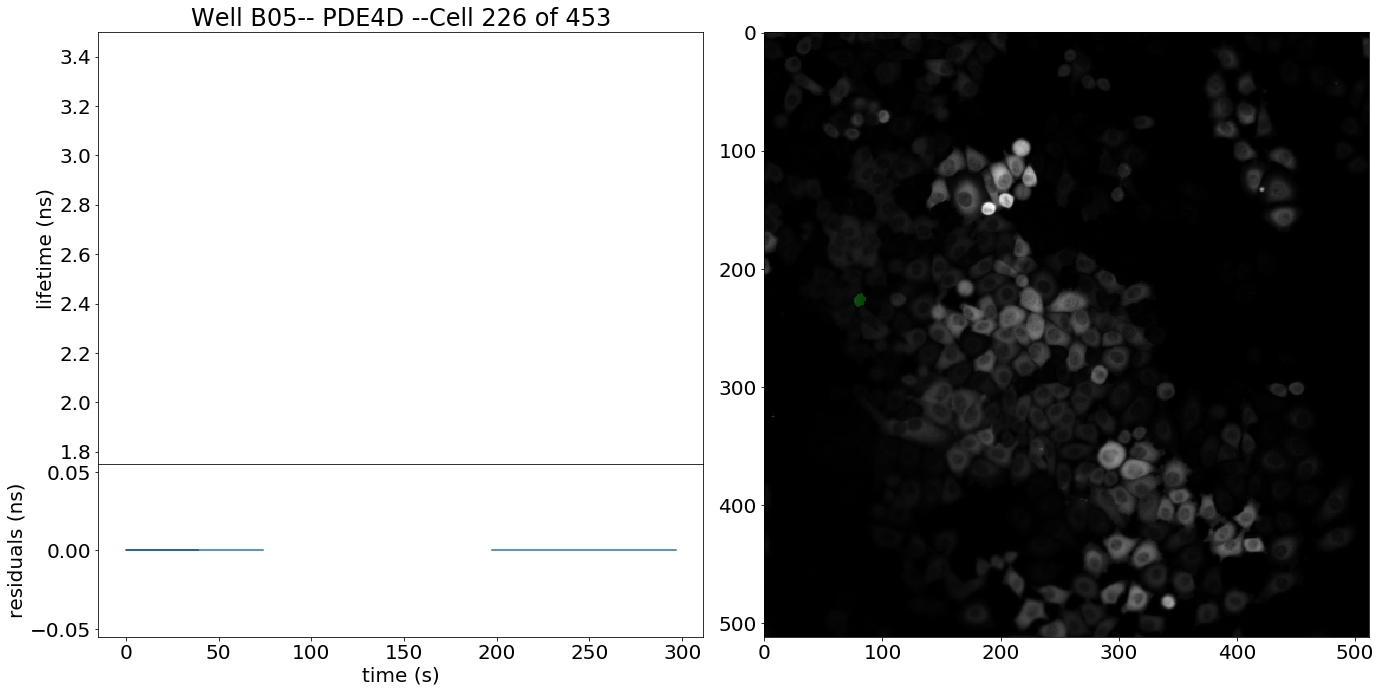

RMSD = nan ns     MAPE = nan %
    --


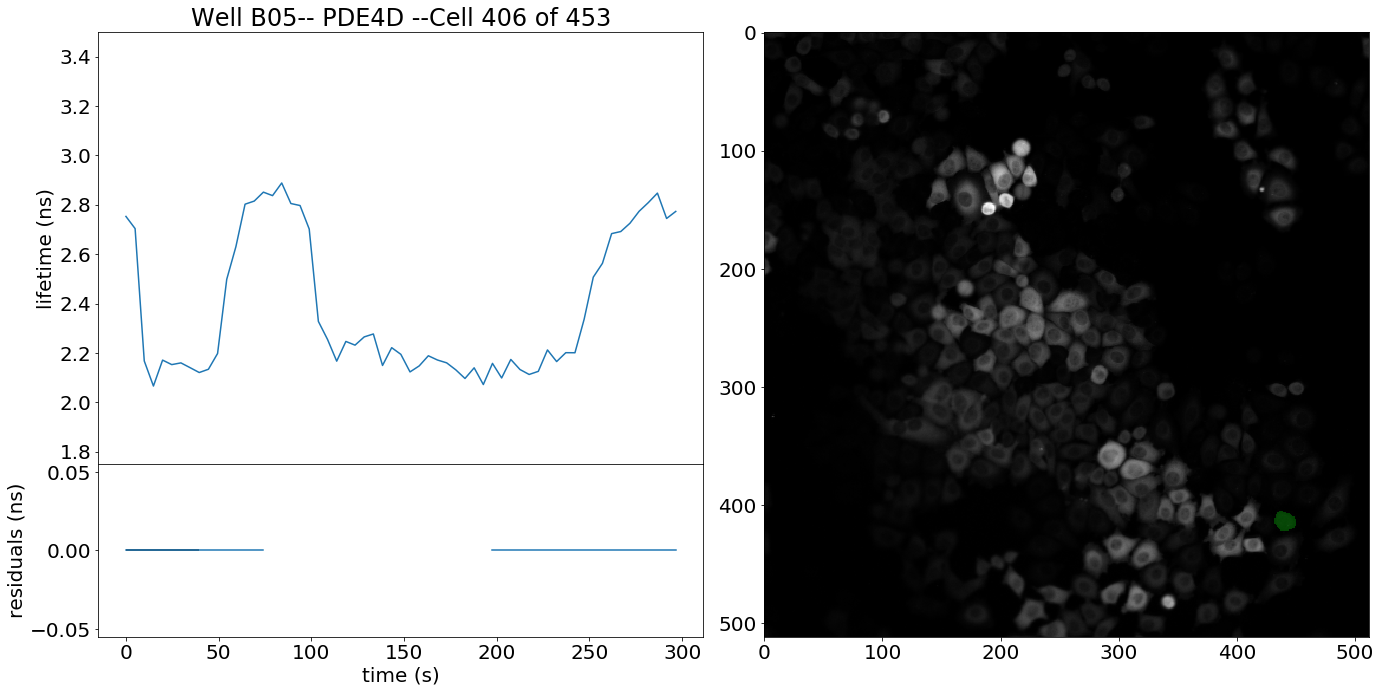

RMSD = nan ns     MAPE = nan %
    --


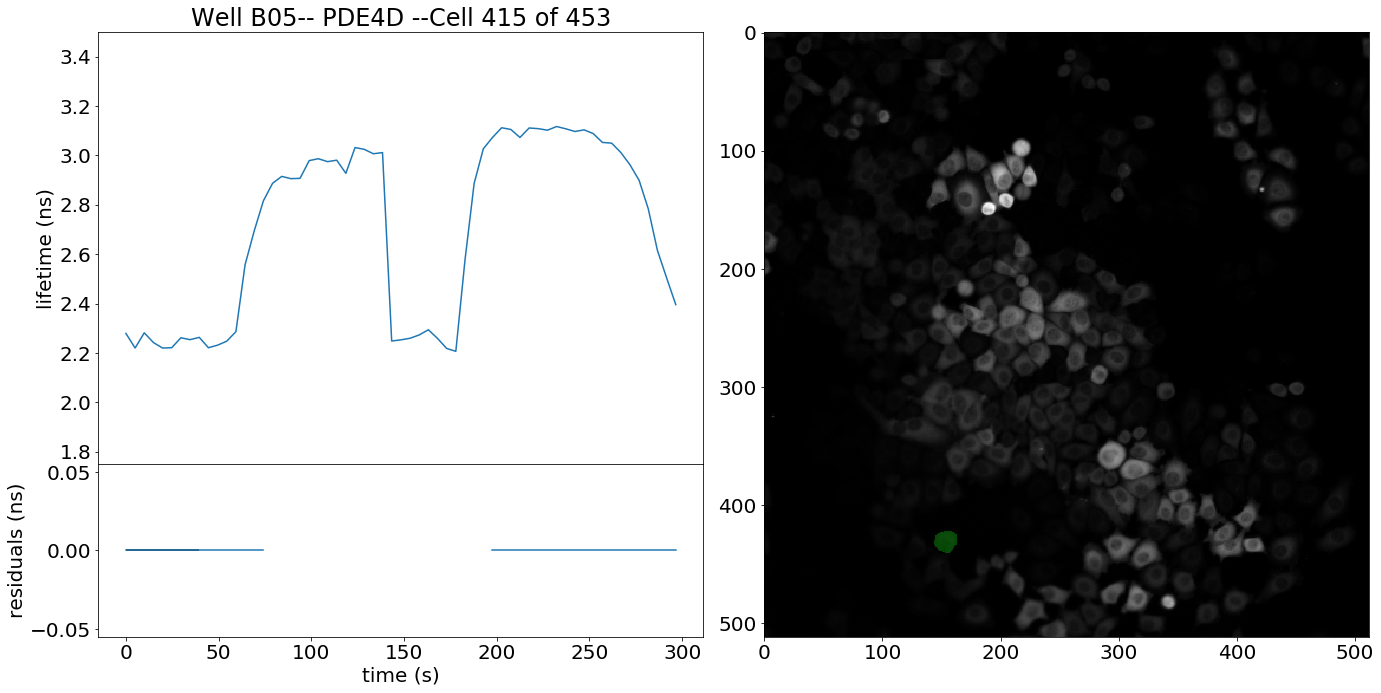

RMSD = nan ns     MAPE = nan %
    --


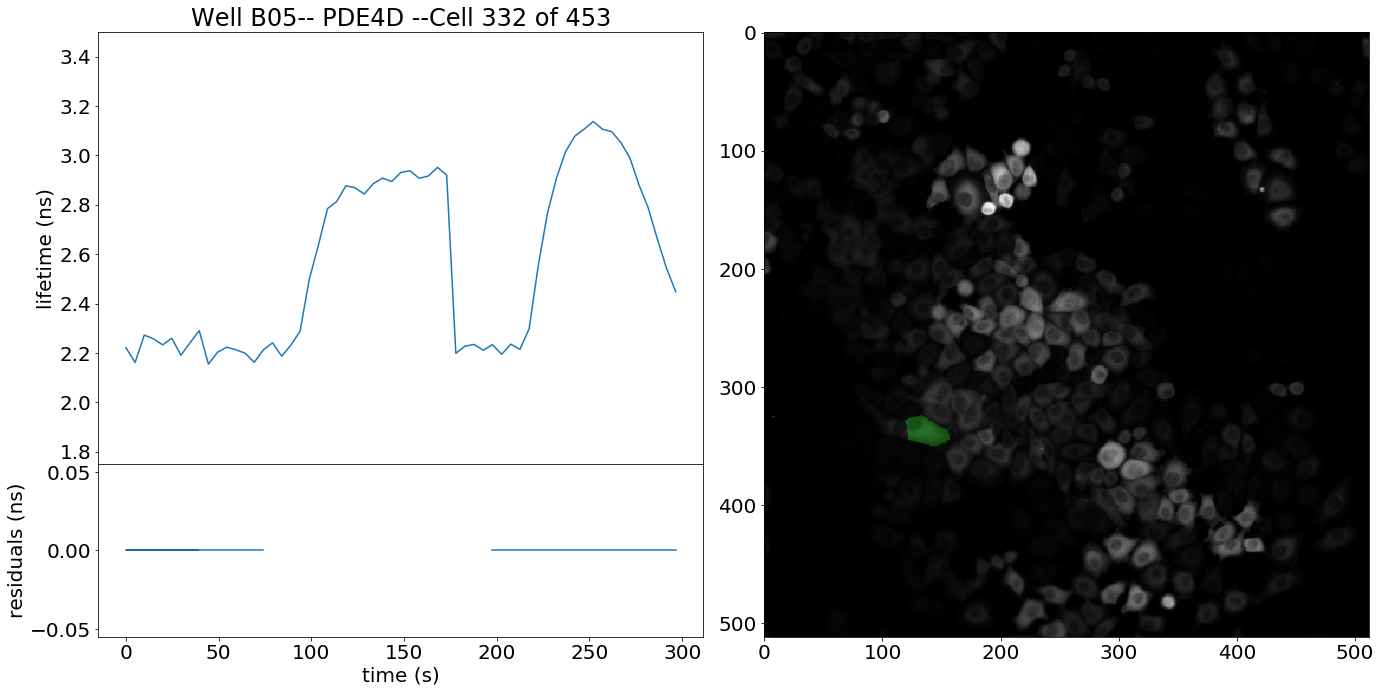

RMSD = nan ns     MAPE = nan %
    --


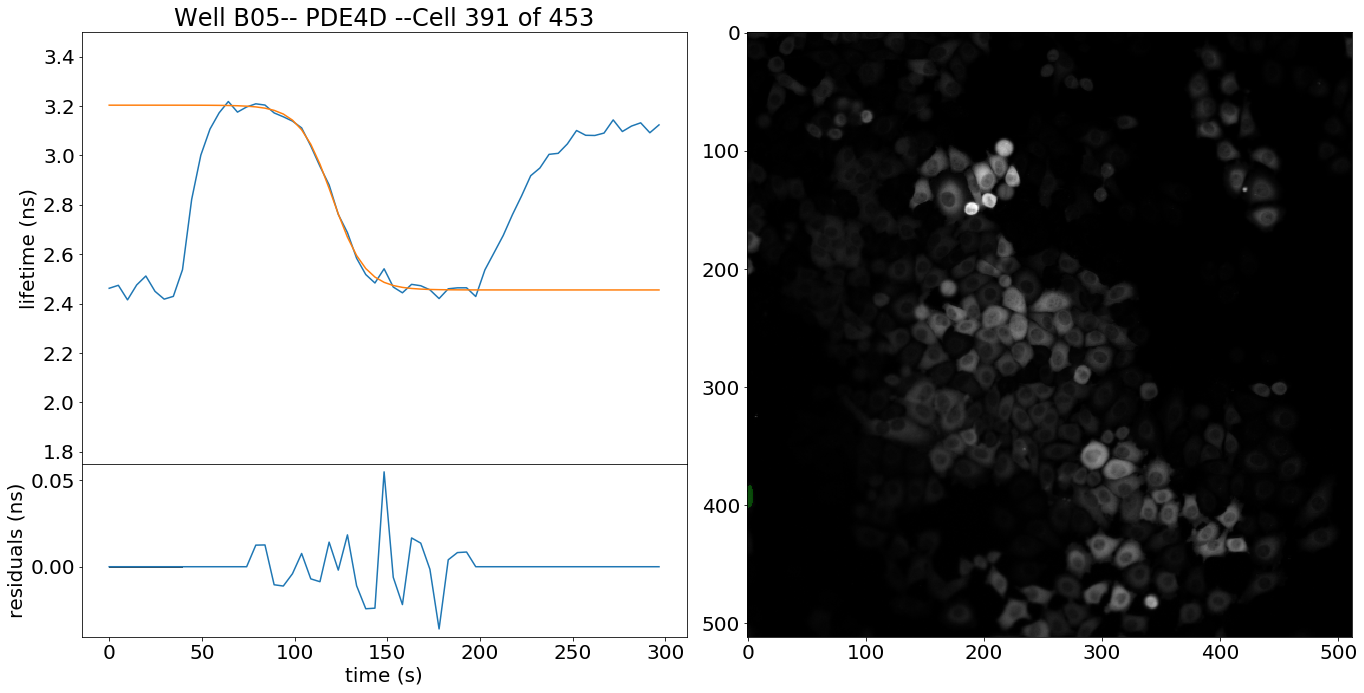

RMSD = 0.018 ns     MAPE = 0.5 %
    --


In [37]:
#trace_ids = [100, 101, 50] # somehow the highlighted cells start at trace-id nr. 1
trace_ids = np.random.randint(1, len(lifetimetraces), size=max_nroi)
for trace_id in trace_ids:
    fit_vals= fit.loc[trace_id,:]
    fit_vals
    xdat = np.arange(0, ntime * frameinterval, frameinterval)
    ydat = lifetimetraces[trace_id]   
    yfit = fit_function(xdat,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown_time(s)'],fit_vals['midpoint(s)'])
    #print(wellName,"  ", condition,"  ", "Cell ", trace_id,  '       n_x =', len(xdat), '  n_y =', len(ydat),'  n_yfit =', len(yfit))
    
    # find the fit-range
    fitrange = np.zeros(shape=2, dtype=int)
    mean_trace = np.mean(lifetimetraces, axis=0)
    
    d_mean_trace = np.diff(mean_trace)
    fitrange[0] = np.argmax(mean_trace[0:int(150 / frameinterval)])  # maximum in the first 150 seconds
    fitrange[1] = ntime
    if forskendpoint:
        # 3 frames before maximum increase after peak.
        fitrange[1] = fitrange[0] + np.argmax(d_mean_trace[fitrange[0]:]) - 1
    
    xdat_selected = xdat[fitrange[0]:fitrange[1]]
    ydat_selected = ydat[fitrange[0]:fitrange[1]]
    yfit_selected = yfit[fitrange[0]:fitrange[1]]
    
    yresid = ydat - yfit #generate residuals but only for fit region
    yresid[0:fitrange[0]]=0
    yresid[fitrange[1]:len(yresid)]=0    
    
    rect_fit = [0.1, 0.5, 1, 1] #double plot the stuff
    rect_resid = [0.1, 0.1, 1, 0.4]
    rect_image = [1.2, 0.1, 1, 1.4]
    fig = plt.figure(figsize = (6*1.4, 6))
    pltFit = fig.add_axes(rect_fit)
    pltResid = fig.add_axes(rect_resid)
    pltImg = fig.add_axes(rect_image)
    pltFit.set_title("Well "+wellName+'-- '+condition+' --Cell '+str(trace_id)+' of '+str(len(lifetimetraces)))
    pltFit.set_ylabel('lifetime (ns)')
    if fixYScale==True:
        pltFit.set_ylim(1.75, 3.5)
    pltResid.set_ylabel('residuals (ns)')
    pltResid.set_xlabel('time (s)')
    pltFit.plot(xdat, ydat, label="exp data")
    pltFit.plot(xdat, yfit, label='fit')
    pltResid.plot(xdat, yresid)
    pltResid.hlines(0,0,len('time (s)')*frameinterval)
    highlighted_ROI = get_cell_image(labelmap_pth,meanimg_pth,trace_id)
    pltImg.imshow(highlighted_ROI)
    plt.show()
   
    
    #  Calculate some measure of fit quality. The residual sum of squares is used to 
    #help you decide if a statistical model is a good fit for your data. 
    SSresid = sum(yresid[fitrange[0]:fitrange[1]]**2)  # The Total SS (TSS or SST) 
    #tells you how much variation there is in the dependent variable. 
    #SStotal = Σ((Yi – mean of Y)**2). or also people use: SStotal = n*var(Y)
    SStotal = len(ydat[fitrange[0]:fitrange[1]]) * np.var(ydat)
    Rsq = 1-(SSresid/SStotal)
    #print("SSresid = %.2f"%SSresid, "   ", "SStotal = %.2f"%SStotal, "   ", "Rsq = %.2f"%Rsq)
    RMSD = np.sqrt(SSresid / len(ydat[fitrange[0]:fitrange[1]]))
    
    #The mean absolute percentage error (MAPE), also known as mean absolute percentage deviation (MAPD),
    #is a measure of prediction accuracy of a forecasting method in statistics, for example in trend estimation.
    #It usually expresses the accuracy as a ratio defined by the formula:
    # MAPE = (1/n) * Σ(|actual – forecast| / |actual|) * 100 
    # The smaller the error, again the better! Below 1% is a good measure for goodness of fit.
    
    MAPE = (100/len(ydat_selected))*sum(abs(ydat_selected-yfit_selected) / ydat_selected)
    print("RMSD = %.3f ns"%RMSD,"   ","MAPE = %.1f"%MAPE, "%")   
    print("    --")
   
    trace_id+=1 #next part controls how they are shown sequentially
    if autoScroll==True:
        time.sleep(scrollTime)
    else:
        a=input("type Enter for Next Trace, or s+Enter to Stop: ")
        if a.lower()=='s':
            trace_id=100000 #exit the loop. somehow break does not work. bloody amateur 